In [10]:
# 데이터 시각화
# 데이터 시각화를 위해선 우선 데이터의 종류를 먼저 이해하는 것이 중요

# 1. 수치형 데이타 => 사칙연산 가능
#  - 연속형 실수형태 (키, 몸무게)
#  - 이산형 정수형태 (A반 학생수 , 인원수)

# 2. 범주형 데이터 => 사칙연산 불가
#  - 순서형  순서있음    학점, 설문조사 점수
#  - 명목형  순서없음    성별, 우편번호

# 명목형 → 막대그래프, 파이차트, Countplot
# 순서형 → 정렬된 막대그래프
# 수치형 → 히스토그램, 박스플롯

# ===================================================

# 막대 → 선 → 히스토그램 → 박스플롯 → 산점도 → 히트맵 순서로 이해

# 실무에서 가장 많이 쓰는 TOP 10
# 막대그래프 → 비교
# 선그래프 → 추세
# 산점도 → 관계
# 히스토그램 → 분포(구간별 단변량)
# 박스플롯 → 이상치
# 히트맵 → 상관관계
# 누적막대 → 구성비
# 파이차트 → 비율
# 트리맵 → 계층
# 산점도 + 회귀선 → 예측

# 한 줄 규칙

# 비교 → 막대 (범주(카테고리)끼리 크기를 비교)
# 변화 → 선
# 관계 → 산점도
# 분포 → 히스토그램
# 비율 → 파이
# 상관 → 히트맵

# 자주 쓰는 plt
# | 코드              | 의미    |
# | --------------- | ----- |
# | `plt.figure()`  | 그림 생성 |
# | `plt.plot()`    | 선그래프  |
# | `plt.bar()`     | 막대그래프 |
# | `plt.scatter()` | 산점도   |
# | `plt.hist()`    | 히스토그램 |
# | `plt.pie()`     | 파이차트  |
# | `plt.title()`   | 제목    |
# | `plt.xlabel()`  | x축    |
# | `plt.ylabel()`  | y축    |
# | `plt.grid()`    | 격자    |
# | `plt.show()`    | 출력    |

In [11]:
import os

if not os.path.exists("/content/NanumGothic.ttf"):
    !wget -O /content/NanumGothic.ttf \
    https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 등록
font_path = "/content/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(
    fname=font_path
).get_name()

plt.rc("font", family=font_name)

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# warning 안나오게
import warnings

warnings.filterwarnings("ignore")

In [13]:
# 1. Seaborn은 Python의 데이터 시각화 라이브러리로, 
#  matplotlib을 기반으로 하고 있지만, 더 직관적이고 고급스러운 그래프를 그릴 수 있도록 도와주는 도구
# 2. 통계적 시각화에 특화
# 3. Seaborn은 pandas DataFrame과의 통합이 매우 잘 되어 있어서, pandas에서 직접 데이터를 처리한 뒤 Seaborn으로 바로 시각화
# 4. Seaborn은 기본적으로 아름다운 색상 팔레트와 디자인을 제공


# 수치형 1개
# - 히스토그램   sns.histplot() ,plt.hist() 
# - 분포도 sns.diplot()
# - 박스플롯 sns.boxplot()

# 수치형 2개 이상(변수 관계 확인)
# - 히트맵 sns.heatmap() = 변수관 상관계수 확인
# - 라인플롯 sns.linplot()
# - 산점도 sns.scatterplot()
# - 페어프롯 sns.pairplot()

# 범주형 

# 범주형 1개
# - 카운트 플롯 sns.countplot()

# 범주형 2개 이상(변수 관계 확인)
# - 막대그래프  sns.barplot()
# - 포인트플롯  sns.pointplot()
# - 박스플롯    sns.boxplot()
# - 바이올린 플롯 sns.violinplot()

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 시각화를 통한 EDA(탐색적 분석)

df_tips = sns.load_dataset("tips")

df_tips.info()

#분석 = 인사이트 도출 
# 1. tips 데이타는 7 개의 컬럼으로 이루어져 있다.
# 2. 3개의 수치형 데이터 와 4개의 범주형 데이터 
# 3. 결측치는 없으며, 244개의 행으로 이루어져 있다.

print(df_tips.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
    total_bill   tip     sex smoker  day    time  size
0        16.99  1.01  Female     No  Sun  Dinner     2
1        10.34  1.66    Male     No  Sun  Dinner     3
2        21.01  3.50    Male     No  Sun  Dinner     3
3        23.68  3.31    Male     No  Sun  Dinner     2
4        24.59  3.61  Female     No  Sun  Dinner     4
5        25.29  4.71    Male     No  Sun  Dinner     4
6         8.77  2.00    Male     No  Sun  Dinner     2
7        26.88 

In [15]:
df_tips.to_excel("tips_all.xlsx",index=False)

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

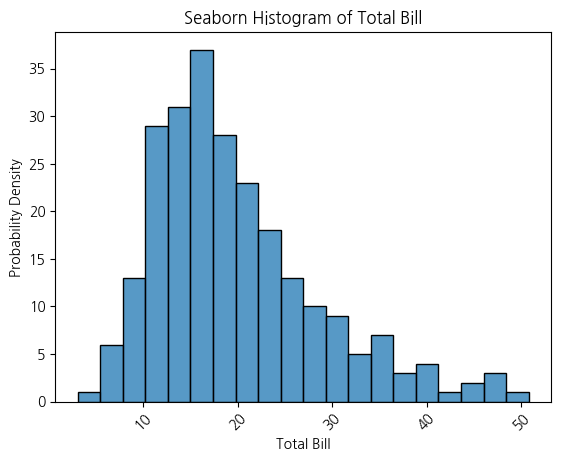

In [17]:
# 분석상 total_bill 과 tips 가 가장 중요한 컬럼으로 인식됨
# tips["total_bill"] 히스토그램을 Seaborn으로 그리기

sns.histplot(data=df_tips,x="total_bill",bins=20)

plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.title("Seaborn Histogram of Total Bill")
plt.xticks(rotation=45)




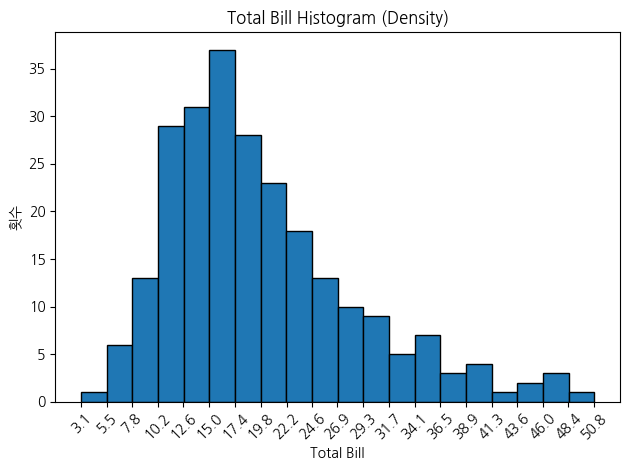

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
tips = sns.load_dataset("tips")

# 히스토그램 정보
bins = 20
counts, bin_edges, _ = plt.hist(
    tips["total_bill"],
    bins=bins,
    density=False,  # 확률 밀도
    edgecolor='black'
)

# x축 눈금 수동 지정: bin 경계값들을 x축 눈금으로 설정
plt.xticks(np.round(bin_edges, 1), rotation=45)  # 필요하면 회전

plt.xlabel("Total Bill")
plt.ylabel("횟수")
plt.title("Total Bill Histogram (Density)")
plt.tight_layout()
plt.show()